In [14]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import ConcatDataset, DataLoader
from torch.optim import AdamW
import sys
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample

# set path to project root and import custom classes and functions
project_root = Path.cwd() / "../../../"
sys.path.append(str(project_root.resolve()))
from utils.classification import StanceNLIDataset, train_bert
from utils.evaluation import evaluate_nli_stance

# set seed and specify the device
seed = 0
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Code running on: {device}")

Code running on: mps


In [6]:
# load main data and hyperparameter tuning results
with open(project_root / "01_data/classification/training_validation_sets/stance/training_set.json", "r") as f:
    data = json.load(f)

# load the results from hyperparameter tuning
with open(project_root / "04_classification_models/stance_classification/bert_nli/hyperparameter_tuning_results/ht_bert_nli_stance.json", "r") as f:
    hyperparameter_tuning_results = json.load(f)

# set the model name
model_name = "MoritzLaurer/deberta-v3-base-zeroshot-v2.0"

In [12]:
epochs = hyperparameter_tuning_results[model_name]["best_epoch"]
lr = hyperparameter_tuning_results[model_name]["best_params"]["lr"]
batch_size = hyperparameter_tuning_results[model_name]["best_params"]["batch_size"]
weight_decay = hyperparameter_tuning_results[model_name]["best_params"]["weight_decay"]

# define the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# create cross-validation object for 5 folds
k = 5
kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
all_labels = [item[0]["stance"] for item in data]

# empty lists for all true and predicted labels
all_true_labels = []
all_pred_labels = []

# randomly split the training data into 5 folds and loop over them
for fold, (train_idx, val_idx) in enumerate(kf.split(data, all_labels)):

    print(f"\nFold number: {fold + 1}")

    # create the model
    model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    label_to_id = model.config.label2id

    # create the training and validation fold based on the provided indices
    train_fold_data = [data[i] for i in train_idx]
    val_fold_data = [data[i] for i in val_idx]

    # unpack validation data (augmentations are not needed)
    val_data = [task[0] for task in val_fold_data]

    # get the original training data
    train_data_original = [task[0] for task in train_fold_data]
    train_dataset = StanceNLIDataset(train_data_original, tokenizer, max_len=128, label2id=label_to_id)
            
    # oversample minority classes to a certain proportion and create datasets
    neg_ann = [r for r in train_fold_data if r[0]["stance"] == "neg"]
    neg_extra = resample(neg_ann, replace=False, n_samples=int(len(neg_ann)*0.5), random_state=0)
    train_data_neg_aug = [task[2] for task in neg_extra]
    train_dataset_neg_aug = StanceNLIDataset(train_data_neg_aug, tokenizer, max_len=128, label2id=label_to_id)
    train_dataset_balanced = ConcatDataset([train_dataset, train_dataset_neg_aug])

    # create the data loader
    train_dataloader = DataLoader(train_dataset_balanced, batch_size=batch_size, shuffle=True)

    # train the model with the optimal configuration
    train_bert(train_dataloader, model, optimizer, epochs, device, which_task="stance")

    # run evaluation
    true_labels, pred_labels = evaluate_nli_stance(
        model=model, data=val_data, tokenizer=tokenizer, device=device
        )
    
    # extend all true and pred lists
    all_true_labels.extend(true_labels)
    all_pred_labels.extend(pred_labels)


Fold number: 1
Epoch 1/4


Training:   0%|          | 0/24 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Training: 100%|██████████| 24/24 [00:19<00:00,  1.22it/s, loss=0.0396]


Average training loss: 0.5575
Epoch 2/4


Training: 100%|██████████| 24/24 [00:13<00:00,  1.83it/s, loss=0.00125]


Average training loss: 0.1356
Epoch 3/4


...

Average training loss: 0.1960
Epoch 3/4


Training: 100%|██████████| 24/24 [00:12<00:00,  1.87it/s, loss=0.000117]


Average training loss: 0.0354
Epoch 4/4


Training: 100%|██████████| 24/24 [00:12<00:00,  1.88it/s, loss=3.6e-5]  


Average training loss: 0.0029


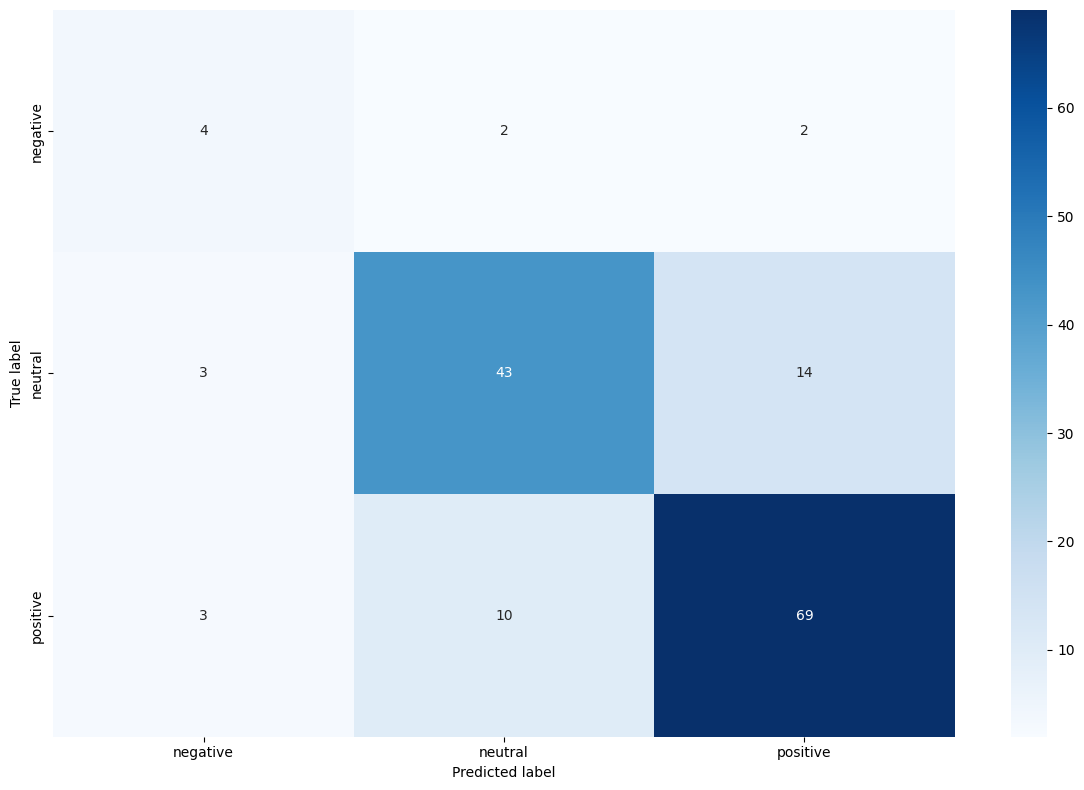

In [24]:
# create confusion matrix as a dataframe
label_remap = {
    "neg": "negative",
    "neutral": "neutral",
    "pos": "positive"
}
all_true_labels = [label_remap[label] for label in all_true_labels]
all_pred_labels = [label_remap[label] for label in all_pred_labels]

labels = sorted(list(set(all_true_labels)))
cm = confusion_matrix(
    all_true_labels,
    all_pred_labels,
    labels=labels
)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# plot it
plt.figure(figsize=(12, 8))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

In [ ]:
# get the most frequent confusion directions
confusions = []

for i, true_label in enumerate(labels):
    for j, pred_label in enumerate(labels):
        if i != j:  # ignore correct predictions
            confusions.append({
                "true": true_label,
                "pred": pred_label,
                "count": cm[i, j]
            })

# sort by frequency descending
confusions = sorted(confusions, key=lambda x: x["count"], reverse=True)